<a href="https://colab.research.google.com/github/rabyaibtesam-lgtm/Machine-learning/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas scikit-learn matplotlib graphviz


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
dataset=pd.read_csv('/content/iris.csv')

In [ ]:
dataset.head()


,sepal.length,sepal.width,petal.length,petal.width,type
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:


print(dataset.isnull().sum())



sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
type            0
dtype: int64


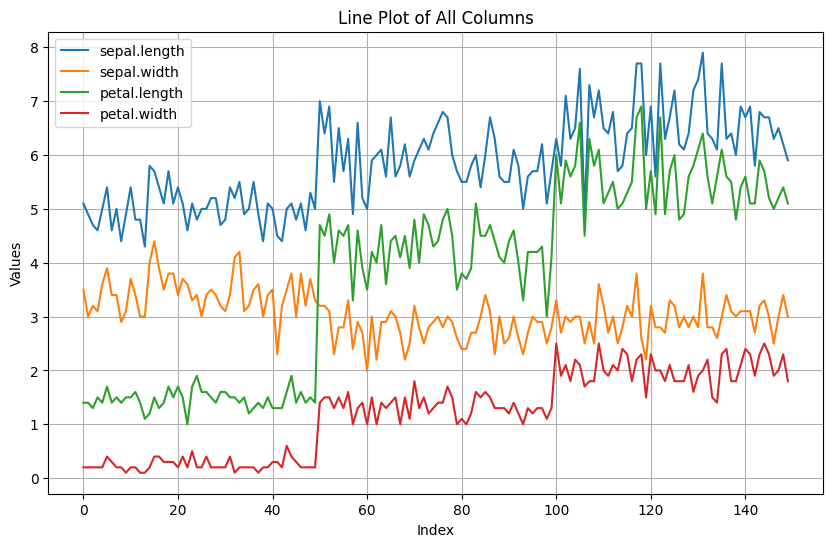

In [ ]:
import matplotlib.pyplot as plt

dataset.plot(kind='line', figsize=(10,6))

plt.title("Line Plot of All Columns")
plt.xlabel("Index")
plt.ylabel("Values")
plt.grid(True)
plt.show()

In [ ]:


# Label Enoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dataset['type'] = le.fit_transform(dataset['type'])


In [ ]:
# Exporting Label Encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [ ]:
X = dataset.drop(columns=['type'])
y= dataset['type']

### Splitting into Training and Testing Dataset

It will be split via the 80/20 rule, meaning 80% of the data will be used to train the model and 20% will be used to test it.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Step 4: Initialize Decision Tree Classifier
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)

In [ ]:
# Step 5: Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# Step 6: Make predictions
y_pred = clf.predict(X_test)

# Step 7: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [ ]:


le.classes_



array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

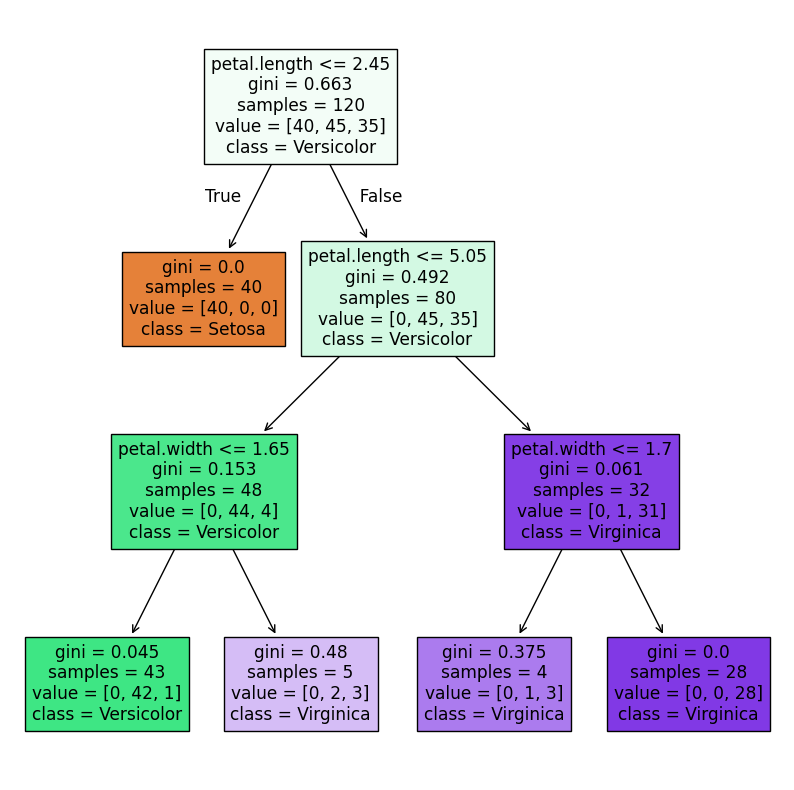

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(
    clf,
    feature_names=X.columns,
    class_names=le.classes_,  # convert to strings
    filled=True
)
plt.show()

In [ ]:

# Take Predictuion on Single Data Point
# Sepal Length, Sepal Width, Petal Length, Petal Width
single_data = [[5.1, 3.5, 3, 0.2]]
predicted_class = clf.predict(single_data)
print("Predicted class for single data point:", le.inverse_transform(predicted_class))


Predicted class for single data point: ['Versicolor']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


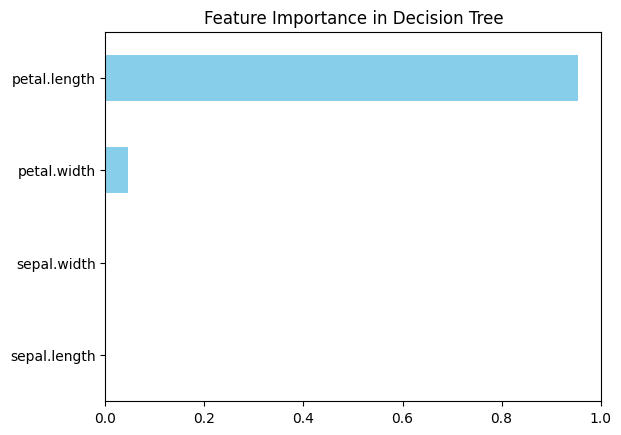

In [ ]:


import pandas as pd

# Feature importance
feat_importance = pd.Series(clf.feature_importances_, index=X.columns)

# Plot
feat_importance.sort_values().plot(kind='barh', color="skyblue")
plt.title("Feature Importance in Decision Tree")
plt.show()



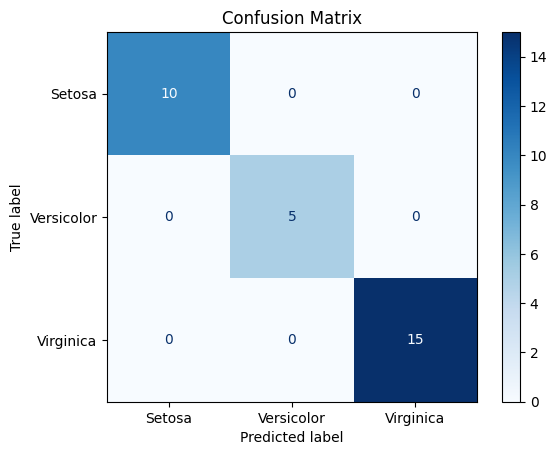

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=le.classes_,
                                        cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [ ]:


import pickle
# Exporting the trained model
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(clf, f)

